# Friction-coupling tests — open/closed-loop ramps + step disturbance (coupled bench rig)

**Rig:** the coupled dev-bench rig — two Nezha motors on **ports 3 and 4** whose
shafts are linked by a friction coupling, so torque applied by one shows up as
load (or assist) on the other. Same rig as `tests/bench/pid_hold_speed.py` and
`tests/bench/ratio_governor_curve.py`.

## The three tests

1. **Open-loop ramp (100 s):** motor 3 held at a constant **+50 % duty**
   (`DEV M 3 DUTY 50` — the velocity PID only runs in VEL mode, so it is fully
   out of the loop). Motor 4 ramps **−50 % → +50 % duty in 1 % steps** on a
   fixed 100 s schedule (~1 s per step). The coupling drags motor 3's measured
   speed around even though its command never changes — the open-loop
   coupling transfer curve.
2. **Closed-loop ramp (100 s):** identical ramp, but motor 3 is held by the
   embedded velocity PID (`DEV M 3 VEL <target>`, boot-tuned 077-007 gains:
   kp=0.0022, ki=0.0018, kff=0.0038, i_max=0.3). The target defaults to the
   open-loop run's motor-3 speed at motor-4 ≈ 0 % duty so both runs share an
   operating point (`CLOSED_LOOP_TARGET` overrides). If the PID rejects the
   disturbance this curve stays flat while the applied-duty panel shows the
   controller effort doing the work.
3. **Step disturbance test (~8 s):** motor 3 under the PID at
   `STEP_HOLD_TARGET` (200 mm/s), motor 4 kicked through `STEP_SCHEDULE`
   (default 0 → −25 % → 0, 1 s each) then stopped, sampled fast the whole
   time. A time-series view of the transient: the initial 0→200 step
   response, the load kick, and the recovery. For the harsher sequences
   (±20 % stop-start, +10/−10/+10 full reversals) just edit `STEP_SCHEDULE`.

The ramp schedule is absolute — step *i* owns its time slot from ramp start —
so each ramp takes exactly `RAMP_TOTAL_TIME` regardless of serial latency;
slow polls cost samples, not schedule.

## Transport notes (why the loops look the way they do)

This bench's direct-USB CDC link drops reply lines in bursts (documented in
`tests/bench/dev_exercise.py`); a lost reply costs the full `read_timeout`
+ 500 ms grace inside `SerialConnection.send`. So:

- **Sampling never waits for a reply.** A `DEV STATE` is cast
  (`send_fast`, no corr-id) every `SAMPLE_PERIOD`, and whatever reply
  bursts arrive are collected passively off the reader thread (a queue
  registered under the empty corr-id — replies to casts are otherwise
  dropped). Measured on this bench: ~10 clean samples/s, zero loss, vs
  ~1/s for the blocking request/reply pattern whose late replies get
  discarded.
- **Mid-test actuation is also fire-and-forget** — duty steps and hold
  re-asserts never stall the schedule; each sample's `applied_*` fields
  independently prove what duty each motor actually had.
- Both motors get `DEV M <n> RESET` before each test — the encoder wedge
  latch (`wedged=1`) otherwise survives from a previous session's stop.

## Caching — tests don't re-run if their data exists

Each test saves its raw samples to its own CSV under `tests/notebooks/out/`.
A run cell that finds its CSV **loads it instead of driving the hardware**
(the whole notebook re-runs offline once all three exist). To re-collect a
test, **delete its CSV** and re-run the cell:

| Test | Data file |
|---|---|
| open-loop ramp | `out/friction_coupling_ramp_open.csv` |
| closed-loop ramp | `out/friction_coupling_ramp_closed.csv` |
| step test | `out/friction_coupling_step.csv` |

**Requirements (hardware runs only):** dev-bench firmware
(`ROBOT_DEV_BUILD=1`, `DEV` family) flashed, robot on direct USB, nothing
else holding the serial port. HITL — a person present, per `tests/CLAUDE.md`.

**Safety:** the serial-silence watchdog is widened to 3 s during each test and
restored to the boot default (1 s) in the test's `finally`, which also sends
`DEV STOP` — motors are never left running on an exception or interrupt.

**Run headless:**
```
uv run jupyter nbconvert --to notebook --execute --inplace \
    --ExecutePreprocessor.timeout=300 tests/notebooks/friction_coupling_sweep.ipynb
```


In [1]:
import pathlib
import queue
import sys
import time

import pandas as pd

# ---------------------------------------------------------------------------
# Paths -- anchored, never CWD-relative. The kernel's working directory
# varies with how the notebook is launched (VS Code's notebookFileRoot,
# jupyter's start dir, nbconvert from the repo root), so nothing below may
# depend on it.
# ---------------------------------------------------------------------------

def _notebook_dir():
    vsc = globals().get("__vsc_ipynb_file__")  # set by VS Code's kernel
    if vsc:
        return pathlib.Path(vsc).resolve().parent
    here = pathlib.Path.cwd().resolve()        # jupyter/nbconvert: CWD is
    for p in (here, *here.parents):            # somewhere in the repo
        if (p / "pyproject.toml").exists():
            return p / "tests" / "notebooks"
    return here


def _repo_root(start):
    for p in (start, *start.parents):
        if (p / "pyproject.toml").exists():
            return p
    raise RuntimeError(f"no pyproject.toml above {start} -- not inside the repo?")


NOTEBOOK_DIR = _notebook_dir()
REPO_ROOT = _repo_root(NOTEBOOK_DIR)
OUT_DIR = NOTEBOOK_DIR / "out"
print(f"repo root:  {REPO_ROOT}")
print(f"output dir: {OUT_DIR}")

# robot_radio normally comes from the project venv (installed editable from
# host/). If this kernel isn't that venv, import from the source tree.
try:
    from robot_radio.io.serial_conn import SerialConnection
    from robot_radio.robot.protocol import NezhaProtocol, parse_response
except ImportError:
    sys.path.insert(0, str(REPO_ROOT / "host"))
    from robot_radio.io.serial_conn import SerialConnection
    from robot_radio.robot.protocol import NezhaProtocol, parse_response

PORT = "/dev/cu.usbmodem2121102"  # direct-USB serial port (same as tests/bench scripts)

HOLD_PORT = 3            # motor under test: held open-loop, then PID-held
SCAN_PORT = 4            # disturbance motor
HOLD_DUTY = 50.0         # [%] open-loop hold duty on HOLD_PORT
SCAN_DUTY_START = -50.0  # [%]
SCAN_DUTY_STOP = 50.0    # [%]
SCAN_DUTY_STEP = 1.0     # [%]

RAMP_TOTAL_TIME = 100.0  # [s] fixed schedule for each whole ramp (~1 s/step)
SPINUP_TIME = 2.5        # [s] hold-motor spin-up / PID convergence pre-ramp
SAMPLE_PERIOD = 0.1      # [s] DEV STATE pump cadence (ramps)
POLL_TIMEOUT = 250       # [ms] reply window for CONFIRMED setup sends only --
                         # sampling never blocks on replies (see pump_drain)

CLOSED_LOOP_TARGET = None  # [mm/s] closed-loop ramp VEL target; None = derive
                           # from the open-loop run at SCAN_PORT duty ~ 0

STEP_HOLD_TARGET = 200.0   # [mm/s] motor-3 VEL target for the step test
STEP_SCHEDULE = [(0.0, 1.0), (-25.0, 1.0), (0.0, 1.0)]  # (duty [%], dwell [s]) motor-4 kicks
STEP_TAIL_TIME = 1.5       # [s] keep sampling after the final stop
STEP_SAMPLE_PERIOD = 0.06  # [s] faster pump cadence for the transient view

SESSION_WATCHDOG_WINDOW = 3000  # [ms] widened during each test
BOOT_WATCHDOG_WINDOW = 1000     # [ms] firmware default -- restored after

OPEN_CSV = OUT_DIR / "friction_coupling_ramp_open.csv"
CLOSED_CSV = OUT_DIR / "friction_coupling_ramp_closed.csv"
STEP_CSV = OUT_DIR / "friction_coupling_step.csv"


repo root:  /Volumes/Proj/proj/RobotProjects/radio-robot-elite
output dir: /Volumes/Proj/proj/RobotProjects/radio-robot-elite/tests/notebooks/out


In [2]:
def dev_send(proto, cmd, timeout=None, retries=6):  # [ms] timeout
    """Confirmed send: send one DEV command, retrying on a silent reply.

    Used only for setup/teardown commands outside the timed sampling windows
    (WD/STOP/RESET/the initial hold) -- mid-test actuation uses dev_cast so a
    burst-dropped reply can't stall the schedule. Safe to retry
    unconditionally: every command here is a pure query or an idempotent
    absolute-value write.
    """
    if timeout is None:
        timeout = POLL_TIMEOUT
    for attempt in range(retries):
        resp = proto.send(cmd, timeout)
        for raw in resp.get("responses", []):
            r = parse_response(raw)
            if r is not None and r.tag in ("OK", "ERR"):
                return r
        if attempt < retries - 1:
            time.sleep(0.1)
    return None


def dev_cast(cmd):
    """Fire-and-forget send (no reply wait) for mid-test actuation. The
    sampler's applied_* fields independently record what each motor got."""
    proto.send_fast(cmd)


def kv_float(r, key):
    if r is None or key not in r.kv:
        return None
    try:
        return float(r.kv[key])
    except ValueError:
        return None


def pump_clear():
    """Drop stale passively-received lines (e.g. from a previous test)."""
    while True:
        try:
            bare_q.get_nowait()
        except queue.Empty:
            return


def pump_drain(rows, loop_label, t0, duty, latest):
    """Drain passively-received DEV STATE bursts; emit one sample row per
    completed burst.

    DEV STATE emits its five OK lines in ascending port order, so the
    highest port we care about closes a burst. `latest` carries each port's
    freshest line across drains, so a burst split across two drains still
    pairs correctly (at most one pump period of skew).
    """
    tail_port = max(HOLD_PORT, SCAN_PORT)
    while True:
        try:
            line = bare_q.get_nowait()
        except queue.Empty:
            return
        r = parse_response(line)
        if (r is None or r.tag != "OK"
                or r.tokens[:2] != ["DEV", "M"] or len(r.tokens) < 3):
            continue
        try:
            port = int(r.tokens[2])
        except ValueError:
            continue
        latest[port] = r
        if port == tail_port:
            h = latest.get(HOLD_PORT)
            s = latest.get(SCAN_PORT)
            rows.append({
                "loop": loop_label,
                "t": time.monotonic() - t0,  # [s] ~arrival (drained every pump cycle)
                "duty_scan": duty,           # [%] commanded on SCAN_PORT
                "vel_hold": kv_float(h, "vel"),   # [mm/s]
                "vel_scan": kv_float(s, "vel"),   # [mm/s]
                "applied_hold": kv_float(h, "applied"),
                "applied_scan": kv_float(s, "applied"),
                "wedged": (kv_float(h, "wedged") == 1.0
                           or kv_float(s, "wedged") == 1.0),
            })


conn = None
proto = None
bare_q = None


def ensure_connected():
    """Open the serial link + DEV preflight on first hardware use. Cells that
    load cached CSVs never touch the port."""
    global conn, proto
    if proto is not None and conn is not None and conn.is_open:
        return
    conn = SerialConnection(port=PORT)
    info = conn.connect()
    if "error" in info:
        raise RuntimeError(f"connect failed: {info['error']}")
    print(f"connected: mode={info.get('mode')}")
    proto = NezhaProtocol(conn)
    # Register the reader thread's empty-corr-id route (private API, by
    # design of this bench tool): replies to send_fast casts carry no #id,
    # and the reader drops them unless a queue is registered under "".
    global bare_q
    bare_q = queue.Queue()
    with conn._reply_lock:
        conn._reply_queues[""] = bare_q
    preflight = dev_send(proto, f"DEV M {HOLD_PORT} STATE")
    if preflight is None or preflight.tag != "OK":
        raise RuntimeError(
            "DEV family not answering -- is the dev-bench firmware "
            f"(ROBOT_DEV_BUILD) flashed? last reply: {preflight.raw if preflight else None}")
    print(preflight.raw)


def cached_or_run(csv_path, runner):
    """Test-data cache: load csv_path if it exists, else run and save."""
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        print(f"cached: {csv_path.name} ({len(df)} samples) -- delete the file to re-run")
        return df
    df = pd.DataFrame(runner())
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    df.to_csv(csv_path, index=False)
    print(f"ran and saved: {csv_path.name} ({len(df)} samples)")
    return df


In [3]:
step_count = int(round((SCAN_DUTY_STOP - SCAN_DUTY_START) / SCAN_DUTY_STEP)) + 1
scan_duties = [SCAN_DUTY_START + i * SCAN_DUTY_STEP for i in range(step_count)]  # [%]


def test_setup(hold_cmd):
    """Shared preamble: widen watchdog, all-stop, clear encoder/wedge state,
    start the hold motor (confirmed sends -- outside any timed window)."""
    dev_send(proto, f"DEV WD {SESSION_WATCHDOG_WINDOW}")
    dev_send(proto, "DEV STOP")
    dev_send(proto, f"DEV M {HOLD_PORT} RESET")
    dev_send(proto, f"DEV M {SCAN_PORT} RESET")
    r = dev_send(proto, hold_cmd)
    print(f"hold: {hold_cmd} -> {r.raw if r else '(no reply)'}")


def ramp_sweep(loop_label, hold_cmd):
    """One ramp: step SCAN_PORT through scan_duties on a fixed time schedule
    while `hold_cmd` keeps HOLD_PORT commanded; sample both motors via
    DEV STATE continuously. Returns raw sample rows.

    The schedule is absolute (step i owns [i*dwell, (i+1)*dwell) from ramp
    start), so the ramp takes RAMP_TOTAL_TIME regardless of per-poll serial
    latency -- slow polls cost samples, not schedule.
    """
    ensure_connected()
    dwell = RAMP_TOTAL_TIME / len(scan_duties)  # [s]
    rows = []
    test_setup(hold_cmd)
    try:
        # Spin-up (open loop) / PID convergence (~1.5 s on the 077-007 bench
        # tuning) before the ramp starts; casts keep the watchdog fed.
        deadline = time.monotonic() + SPINUP_TIME
        while time.monotonic() < deadline:
            dev_cast("DEV STATE")
            time.sleep(SAMPLE_PERIOD)
        pump_clear()   # discard spin-up bursts -- not part of the ramp

        dev_cast(f"DEV M {SCAN_PORT} DUTY {scan_duties[0]:g}")
        t0 = time.monotonic()
        idx = 0
        latest = {}
        while time.monotonic() - t0 < RAMP_TOTAL_TIME:
            i = min(int((time.monotonic() - t0) / dwell), len(scan_duties) - 1)
            if i != idx:
                idx = i
                dev_cast(f"DEV M {SCAN_PORT} DUTY {scan_duties[i]:g}")
                # Re-assert the hold (idempotent: setDutyCycle/setVelocity
                # just restage the target, no PID-state reset) so a missed
                # watchdog neutral can't silently zero the held motor.
                dev_cast(hold_cmd)
            dev_cast("DEV STATE")
            time.sleep(SAMPLE_PERIOD)
            pump_drain(rows, loop_label, t0, scan_duties[idx], latest)
    finally:
        dev_send(proto, "DEV STOP")
        dev_send(proto, f"DEV WD {BOOT_WATCHDOG_WINDOW}")

    print(f"{loop_label}: {len(rows)} samples over {len(scan_duties)} duty steps")
    return rows


def step_test():
    """Step disturbance test: HOLD_PORT under the PID at STEP_HOLD_TARGET;
    SCAN_PORT kicked through STEP_SCHEDULE then stopped; fast continuous
    sampling from the hold command onward so the 0->target step response is
    captured too. Returns raw sample rows (t=0 at the hold command)."""
    ensure_connected()
    rows = []

    dev_send(proto, f"DEV WD {SESSION_WATCHDOG_WINDOW}")
    dev_send(proto, "DEV STOP")
    dev_send(proto, f"DEV M {HOLD_PORT} RESET")
    dev_send(proto, f"DEV M {SCAN_PORT} RESET")

    pump_clear()
    latest = {}
    t0 = time.monotonic()
    dev_cast(f"DEV M {HOLD_PORT} VEL {STEP_HOLD_TARGET:g}")
    print(f"step: DEV M {HOLD_PORT} VEL {STEP_HOLD_TARGET:g} (cast)")

    def sample_until(deadline, duty):  # [s] monotonic deadline, [%] duty
        while time.monotonic() < deadline:
            dev_cast("DEV STATE")
            time.sleep(STEP_SAMPLE_PERIOD)
            pump_drain(rows, "step", t0, duty, latest)

    try:
        # Convergence pre-roll -- sampled, it's part of the story.
        sample_until(t0 + SPINUP_TIME, 0.0)

        for duty, dwell in STEP_SCHEDULE:
            dev_cast(f"DEV M {SCAN_PORT} DUTY {duty:g}")
            sample_until(time.monotonic() + dwell, duty)

        # Final stop of the disturbance motor; sample the recovery tail.
        dev_cast(f"DEV M {SCAN_PORT} DUTY 0")
        sample_until(time.monotonic() + STEP_TAIL_TIME, 0.0)
    finally:
        dev_send(proto, "DEV STOP")
        dev_send(proto, f"DEV WD {BOOT_WATCHDOG_WINDOW}")

    print(f"step: {len(rows)} samples over {len(STEP_SCHEDULE)} kicks")
    return rows


In [4]:
df_open = cached_or_run(
    OPEN_CSV, lambda: ramp_sweep("open", f"DEV M {HOLD_PORT} DUTY {HOLD_DUTY:g}"))


connected: mode=direct


OK DEV M 3 pos=0.0 vel=0.0 applied=0.00 wedged=1 conn=1 #2


hold: DEV M 3 DUTY 50 -> OK DEV M 3 applied=0.50 #10


open: 961 samples over 101 duty steps
ran and saved: friction_coupling_ramp_open.csv (961 samples)


In [5]:
if CLOSED_CSV.exists():
    df_closed = pd.read_csv(CLOSED_CSV)
    target = float(df_closed["target"].iloc[0])  # [mm/s] as collected
    print(f"cached: {CLOSED_CSV.name} ({len(df_closed)} samples, "
          f"target={target:g} mm/s) -- delete the file to re-run")
else:
    if CLOSED_LOOP_TARGET is not None:
        target = float(CLOSED_LOOP_TARGET)  # [mm/s]
    else:
        # Match the open-loop operating point: motor 3's measured speed
        # while motor 4 is ~unpowered.
        near_zero = df_open[(df_open["duty_scan"].abs() <= 2.0)
                            & df_open["vel_hold"].notna()]
        target = round(float(near_zero["vel_hold"].mean())) if not near_zero.empty else 150.0  # [mm/s]
    print(f"closed-loop VEL target: {target:g} mm/s")
    df_closed = pd.DataFrame(ramp_sweep("closed", f"DEV M {HOLD_PORT} VEL {target:g}"))
    df_closed["target"] = target
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    df_closed.to_csv(CLOSED_CSV, index=False)
    print(f"ran and saved: {CLOSED_CSV.name} ({len(df_closed)} samples)")


closed-loop VEL target: 204 mm/s


hold: DEV M 3 VEL 204 -> OK DEV M 3 vel=204.0 #20


closed: 962 samples over 101 duty steps
ran and saved: friction_coupling_ramp_closed.csv (962 samples)


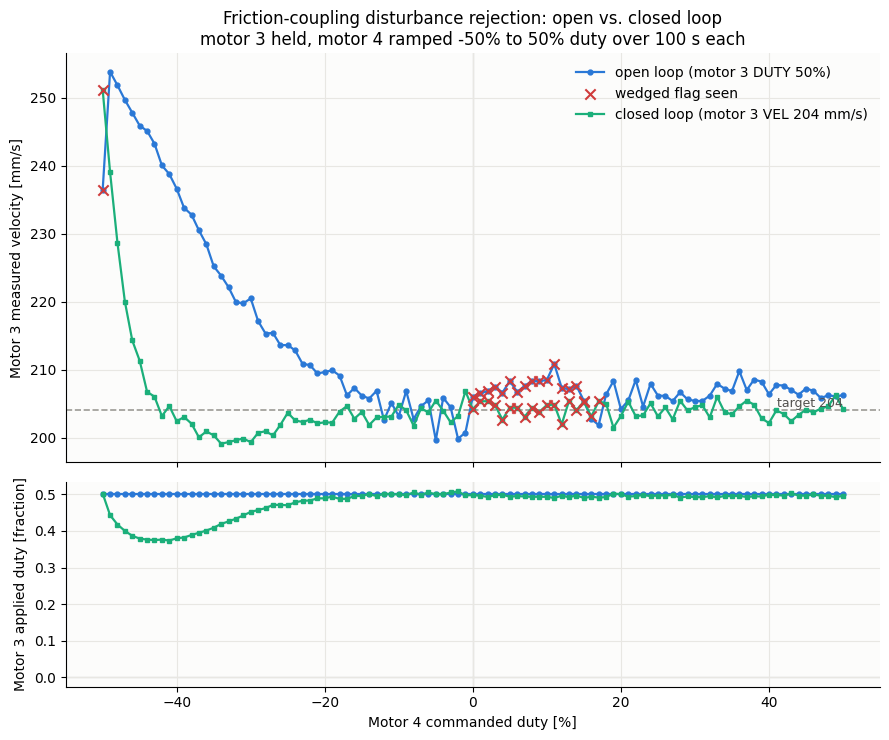

In [6]:
import matplotlib.pyplot as plt

BLUE = "#2a78d6"  # open loop
AQUA = "#1baf7a"  # closed loop

df = pd.concat([df_open, df_closed], ignore_index=True)
agg = (df.dropna(subset=["vel_hold"])
         .groupby(["loop", "duty_scan"], as_index=False)
         .agg(vel_hold_mean=("vel_hold", "mean"),
              applied_hold_mean=("applied_hold", "mean"),
              wedged_any=("wedged", "max")))

fig, (ax_v, ax_d) = plt.subplots(2, 1, figsize=(9, 7.5), sharex=True,
                                 height_ratios=[2, 1], facecolor="white")
for ax in (ax_v, ax_d):
    ax.set_facecolor("#fcfcfb")
    ax.grid(True, color="#e8e7e3", lw=0.8, zorder=0)
    ax.axvline(0, color="#d8d7d3", lw=1, zorder=1)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

series = [("open", BLUE, "o", f"open loop (motor {HOLD_PORT} DUTY {HOLD_DUTY:g}%)"),
          ("closed", AQUA, "s", f"closed loop (motor {HOLD_PORT} VEL {target:g} mm/s)")]
wedged_labeled = False
for loop_label, color, marker, label in series:
    d = agg[agg["loop"] == loop_label]
    ax_v.plot(d["duty_scan"], d["vel_hold_mean"], color=color, marker=marker,
              ms=3.5, lw=1.6, zorder=3, label=label)
    ax_d.plot(d["duty_scan"], d["applied_hold_mean"], color=color, marker=marker,
              ms=3.5, lw=1.6, zorder=3)
    w = d[d["wedged_any"]]
    if not w.empty:
        ax_v.scatter(w["duty_scan"], w["vel_hold_mean"], marker="x",
                     color="#d03b3b", s=55, zorder=4,
                     label=None if wedged_labeled else "wedged flag seen")
        wedged_labeled = True

ax_v.axhline(target, color="#9b9a94", lw=1.2, ls="--", zorder=2)
ax_v.text(SCAN_DUTY_STOP, target, f" target {target:g}", color="#52514e",
          va="bottom", ha="right", fontsize=9)
ax_v.set_ylabel(f"Motor {HOLD_PORT} measured velocity [mm/s]")
ax_v.set_title("Friction-coupling disturbance rejection: open vs. closed loop\n"
               f"motor {HOLD_PORT} held, motor {SCAN_PORT} ramped "
               f"{SCAN_DUTY_START:g}% to {SCAN_DUTY_STOP:g}% duty over "
               f"{RAMP_TOTAL_TIME:g} s each")
ax_v.legend(frameon=False)

ax_d.axhline(0, color="#d8d7d3", lw=1, zorder=1)
ax_d.set_ylabel(f"Motor {HOLD_PORT} applied duty [fraction]")
ax_d.set_xlabel(f"Motor {SCAN_PORT} commanded duty [%]")

fig.tight_layout()
fig.savefig(OUT_DIR / "friction_coupling_ramp.png", dpi=150)
plt.show()


In [7]:
df_step = cached_or_run(STEP_CSV, step_test)


step: DEV M 3 VEL 200 (cast)


step: 111 samples over 3 kicks
ran and saved: friction_coupling_step.csv (111 samples)


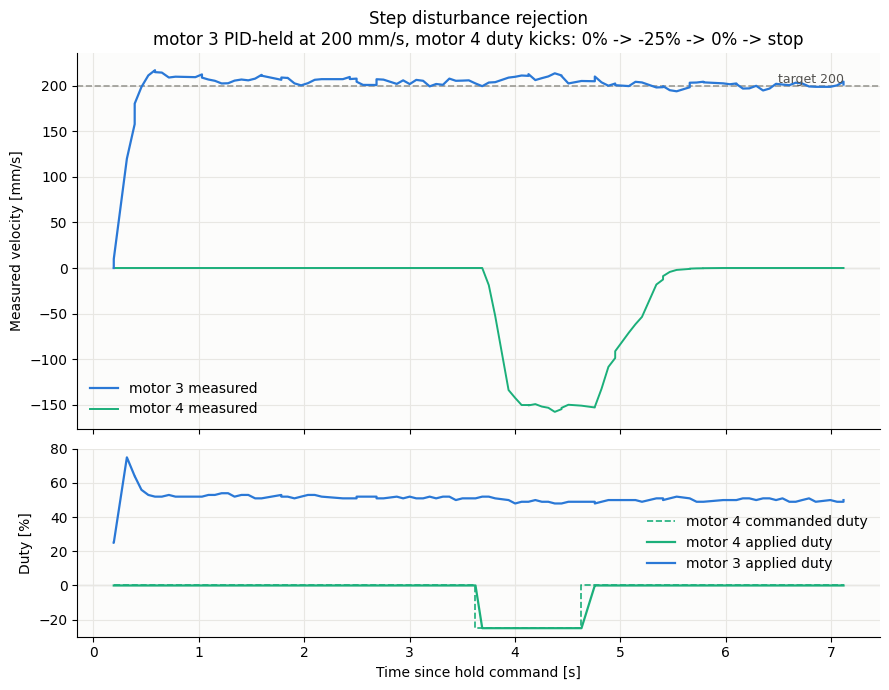

In [8]:
fig, (ax_v, ax_u) = plt.subplots(2, 1, figsize=(9, 7), sharex=True,
                                 height_ratios=[2, 1], facecolor="white")
for ax in (ax_v, ax_u):
    ax.set_facecolor("#fcfcfb")
    ax.grid(True, color="#e8e7e3", lw=0.8, zorder=0)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

ax_v.plot(df_step["t"], df_step["vel_hold"], color=BLUE, lw=1.6, zorder=3,
          label=f"motor {HOLD_PORT} measured")
ax_v.plot(df_step["t"], df_step["vel_scan"], color=AQUA, lw=1.4, zorder=2,
          label=f"motor {SCAN_PORT} measured")
ax_v.axhline(STEP_HOLD_TARGET, color="#9b9a94", lw=1.2, ls="--", zorder=2)
ax_v.text(float(df_step["t"].max()), STEP_HOLD_TARGET,
          f" target {STEP_HOLD_TARGET:g}", color="#52514e",
          va="bottom", ha="right", fontsize=9)
ax_v.axhline(0, color="#d8d7d3", lw=1, zorder=1)
ax_v.set_ylabel("Measured velocity [mm/s]")
ax_v.set_title("Step disturbance rejection\n"
               f"motor {HOLD_PORT} PID-held at {STEP_HOLD_TARGET:g} mm/s, "
               f"motor {SCAN_PORT} duty kicks: "
               + " -> ".join(f"{d:g}%" for d, _ in STEP_SCHEDULE) + " -> stop")
ax_v.legend(frameon=False)

ax_u.step(df_step["t"], df_step["duty_scan"], where="post", color=AQUA,
          lw=1.2, ls="--", zorder=2, label=f"motor {SCAN_PORT} commanded duty")
ax_u.plot(df_step["t"], df_step["applied_scan"] * 100.0, color=AQUA,
          lw=1.6, zorder=3, label=f"motor {SCAN_PORT} applied duty")
ax_u.plot(df_step["t"], df_step["applied_hold"] * 100.0, color=BLUE,
          lw=1.6, zorder=3, label=f"motor {HOLD_PORT} applied duty")
ax_u.axhline(0, color="#d8d7d3", lw=1, zorder=1)
ax_u.set_ylabel("Duty [%]")
ax_u.set_xlabel("Time since hold command [s]")
ax_u.legend(frameon=False)

fig.tight_layout()
fig.savefig(OUT_DIR / "friction_coupling_step.png", dpi=150)
plt.show()


In [9]:
if conn is not None and conn.is_open:
    dev_send(proto, f"DEV WD {BOOT_WATCHDOG_WINDOW}")
    conn.disconnect()
    print("serial closed")
else:
    print("no hardware session was opened (all tests served from cache)")


serial closed
